# Gap / cavity edge picker  —  Huang+2018 half-depth method
Interactive 2-click tool: click the gap dip then the adjacent ring peak.

**Controls**
- **Click 1** → `gap_dip`: click the gap minimum r_d
- **Click 2** → `ring_peak`: click the adjacent ring maximum r_b
- **Right-click** → undo last gap set
- **Inner cavity toggle** → ON: r_di = r_d − 1×FWHM (no leftward I_mean search); only r_do computed via half-depth. Use for cavities where profile rises monotonically to centre.
- **FWHM field** → editable; auto-filled from beam_info but override if needed
- **Disk dropdown** → auto-saves, then loads next disk
- Gaps are **auto-saved** after each click 2 — no Save button needed

In [57]:
import sys, pickle, os, csv
import numpy as np

# needed so pickle can find DiskResiduals_Median_SNR when deserialising
sys.path.insert(0, r'D:\CPD_MPIA\Median_SNR')

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime

# paths
DATA_DIR = r'D:\exoALMA_disk_data'
PKL_FILE = r'D:\CPD_MPIA\Median_SNR\disk_object_files\all_disks.pkl'
LOG_FILE = r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_clicks.csv'

# load disk objects
with open(PKL_FILE, 'rb') as f:
    all_disks = pickle.load(f)

DISKS = sorted(all_disks.keys())
print(f'Loaded {len(DISKS)} disks: {DISKS}')

def get_beam_fwhm(disk):
    """Geometric-mean FWHM [arcsec] at robust=-0.5 from stored beam_info."""
    bi   = all_disks[disk].beam_info.get('-0.5', {})
    bmaj = bi.get('beam_x_arcsec', None)
    bmin = bi.get('beam_y_arcsec', None)
    if bmaj and bmin:
        return float(np.sqrt(bmaj * bmin))
    return float(getattr(all_disks[disk], 'beam_arcsec', 0.065))  # fallback

def load_profile(disk):
    """Load robust=-0.5 CLEAN profile. Returns r_as, r_au, I_mJy, dI_mJy."""
    path = os.path.join(DATA_DIR, disk, f'{disk}_CLEAN_profile_robust-05.txt')
    d = np.loadtxt(path, comments='#')
    return d[:, 0], d[:, 1], d[:, 2], d[:, 3]

# sanity check
for disk in DISKS:
    print(f'  {disk:15s}  beam FWHM = {get_beam_fwhm(disk):.4f}"')


Loaded 15 disks: ['AA_Tau', 'CQ_Tau', 'DM_Tau', 'HD_135344B', 'HD_143006', 'HD_34282', 'J1604', 'J1615', 'J1842', 'J1852', 'LkCa_15', 'MWC_758', 'PDS_66', 'SY_Cha', 'V4046_Sgr']
  AA_Tau           beam FWHM = 0.0632"
  CQ_Tau           beam FWHM = 0.0695"
  DM_Tau           beam FWHM = 0.0632"
  HD_135344B       beam FWHM = 0.0827"
  HD_143006        beam FWHM = 0.0800"
  HD_34282         beam FWHM = 0.0601"
  J1604            beam FWHM = 0.0832"
  J1615            beam FWHM = 0.0900"
  J1842            beam FWHM = 0.0831"
  J1852            beam FWHM = 0.0840"
  LkCa_15          beam FWHM = 0.0664"
  MWC_758          beam FWHM = 0.0873"
  PDS_66           beam FWHM = 0.0826"
  SY_Cha           beam FWHM = 0.0791"
  V4046_Sgr        beam FWHM = 0.0800"


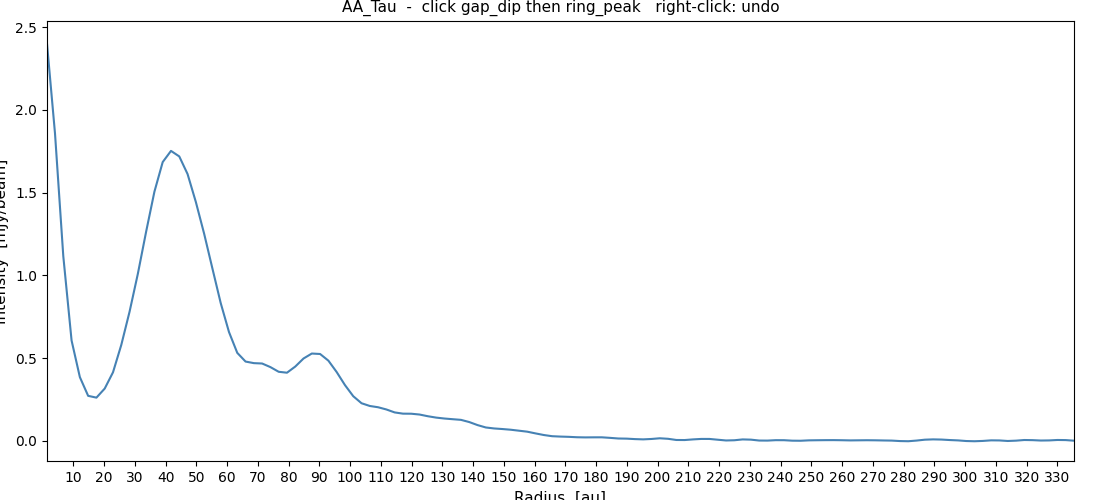

In [58]:
%matplotlib widget

# ── widgets ──────────────────────────────────────────────────────────────
w_disk = widgets.Dropdown(
    options=DISKS, value=DISKS[0], description='Disk:',
    layout=widgets.Layout(width='200px'))

w_fwhm = widgets.BoundedFloatText(
    value=0.065, min=0.005, max=1.0, step=0.001,
    description='FWHM ":', style={'description_width': '60px'},
    layout=widgets.Layout(width='160px'),
    tooltip='Beam FWHM arcsec — auto-filled, editable for cavity inner-edge width')

w_fwhm_mult = widgets.BoundedFloatText(
    value=1.0, min=0.1, max=10.0, step=0.5,
    description='×FWHM:', style={'description_width': '45px'},
    layout=widgets.Layout(width='120px'),
    tooltip='Multiplier for FWHM inner-edge width in cavity mode (0.5, 1, 2 ...)')

w_cavity = widgets.ToggleButton(
    value=False, description='Inner cavity',
    button_style='warning',
    layout=widgets.Layout(width='120px'),
    tooltip='ON: r_di = r_d - N×FWHM instead of I_mean crossing (for cavities)')

w_save = widgets.Button(
    description='Save', button_style='success',
    layout=widgets.Layout(width='80px'))

w_status = widgets.HTML(value='')

top_bar = widgets.HBox(
    [w_disk, w_fwhm, w_fwhm_mult, w_cavity, w_save, w_status],
    layout=widgets.Layout(align_items='center', gap='10px'))

# ── shared mutable state ─────────────────────────────────────────────────
_s = dict(
    disk=None, r_as=None, r_au=None, I=None, dI=None,
    r_fine=None, I_fine=None, dist=None,
    gap_sets=[],   # completed: {gap_dip, ring_peak, inner_edge, outer_edge, I_mean, method, artists}
    pending=None)  # waiting for ring_peak: {r_au, r_arcsec, I_mJy, timestamp, art_line, art_text}

fig, ax = plt.subplots(figsize=(11, 5))
plt.tight_layout()

# ── helpers ──────────────────────────────────────────────────────────────
def _refresh_status():
    disk = _s.get('disk') or '—'
    dist = _s.get('dist')
    fwhm_as = w_fwhm.value
    if dist:
        fwhm_au = fwhm_as * dist
        info = (f'<span style="color:grey;font-size:11px">' 
                f'{disk} &nbsp;|&nbsp; d={dist} pc &nbsp;|&nbsp; '
                f'FWHM={fwhm_as:.4f}" = {fwhm_au:.1f} AU</span>')
    else:
        info = ''
    mode = ' [cavity]' if w_cavity.value else ''
    if _s['pending'] is None:
        click_lbl = f'<b style="color:tomato;font-size:13px">&nbsp; Next: gap_dip{mode}</b>'
    else:
        click_lbl = f'<b style="color:mediumseagreen;font-size:13px">&nbsp; Next: ring_peak{mode}</b>'
    w_status.value = info + click_lbl

def _interp_r(r_val):
    """Returns (I_mJy, r_arcsec) for r_val in AU."""
    I_val    = float(np.interp(r_val, _s['r_au'], _s['I']))
    r_as_val = float(_s['r_as'][np.argmin(np.abs(_s['r_au'] - r_val))])
    return I_val, r_as_val

def _compute_edges(r_d, r_b, cavity=False):
    """
    Compute gap edges.
    cavity=False: full Huang+2018 — both edges from I_mean = 0.5*(I_d + I_b) crossing.
    cavity=True:  r_di = r_d - 1xFWHM_au (no leftward search);
                  r_do = I_mean crossing between r_d and r_b (exterior ring only).
    Returns (r_di, r_do, I_mean, method_str).
    """
    r_fine, I_fine = _s['r_fine'], _s['I_fine']
    I_d    = float(np.interp(r_d, r_fine, I_fine))
    I_b    = float(np.interp(r_b, r_fine, I_fine))
    I_mean = 0.5 * (I_d + I_b)

    def _first_cross_up(rv, Iv, fallback):
        for k in range(len(rv) - 1):
            if Iv[k] <= I_mean <= Iv[k+1]:
                f = (I_mean - Iv[k]) / (Iv[k+1] - Iv[k] + 1e-30)
                return float(rv[k] + f * (rv[k+1] - rv[k]))
        return fallback

    def _last_cross_dn(rv, Iv, fallback):
        for k in range(len(rv) - 1, 0, -1):
            if Iv[k] <= I_mean <= Iv[k-1]:
                f = (I_mean - Iv[k]) / (Iv[k-1] - Iv[k] + 1e-30)
                return float(rv[k] + f * (rv[k-1] - rv[k]))
        return fallback

    if cavity:
        # ── inner cavity mode ──────────────────────────────────────────
        # r_di: N×FWHM inward from the dip
        fwhm_au = w_fwhm.value * w_fwhm_mult.value * _s['dist']
        r_di = max(float(_s['r_au'][0]), r_d - fwhm_au)
        # r_do: exterior ring only — first I_mean crossing rightward from r_d
        msk = (r_fine >= r_d) & (r_fine <= max(r_b, r_d))
        r_do = _first_cross_up(r_fine[msk], I_fine[msk], float(r_fine[msk][-1]))
        method = f'cavity_{w_fwhm_mult.value:g}fwhm'
    elif r_b > r_d:
        # ── exterior ring — standard Huang+2018 ───────────────────────
        msk = (r_fine >= r_d) & (r_fine <= r_b)
        r_do = _first_cross_up(r_fine[msk], I_fine[msk], float(r_fine[msk][-1]))
        msk2 = r_fine <= r_d
        r_di = _last_cross_dn(r_fine[msk2], I_fine[msk2], float(r_fine[msk2][0]))
        method = 'huang2018'
    else:
        # ── interior ring — standard Huang+2018 ───────────────────────
        msk = (r_fine >= r_b) & (r_fine <= r_d)
        r_di = _first_cross_up(r_fine[msk], I_fine[msk], float(r_fine[msk][0]))
        msk2 = r_fine >= r_d
        r_do = _first_cross_up(r_fine[msk2], I_fine[msk2], float(r_fine[msk2][-1]))
        method = 'huang2018'

    return r_di, r_do, I_mean, method

def _draw_set(gs):
    """Draw a completed gap set. Returns list of artists."""
    r_d    = gs['gap_dip']['r_au']
    r_di   = gs['inner_edge']['r_au']
    r_do   = gs['outer_edge']['r_au']
    I_mean = gs['I_mean']
    arts = []
    arts.append(ax.axvline(r_d, color='tomato', lw=1.6, ls='--', alpha=0.9))
    arts.append(ax.axvspan(r_di, r_do, alpha=0.25, color='gold'))
    arts.append(ax.hlines(I_mean, r_di, r_do,
                          colors='darkgoldenrod', lw=1.2, ls=':', alpha=0.9))
    return arts

def _draw_pending_dip(r_d):
    vl = ax.axvline(r_d, color='tomato', lw=1.6, ls='--', alpha=0.7)
    ylo, yhi = ax.get_ylim()
    txt = ax.text(r_d, yhi - 0.03*(yhi - ylo), f'{r_d:.1f} AU',
                  color='tomato', fontsize=7, ha='center', va='top',
                  rotation=90, clip_on=True)
    return vl, txt

def _redraw_profile():
    ax.clear()
    r_au, I = _s['r_au'], _s['I']
    ax.plot(r_au, I, color='steelblue', lw=1.5)
    ax.set_xlabel('Radius  [au]', fontsize=11)
    ax.set_ylabel('Intensity  [mJy/beam]', fontsize=11)
    ax.set_xlim(r_au.min(), r_au.max())
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_title(f"{_s['disk']}  -  click gap_dip then ring_peak   right-click: undo",
                 fontsize=11)
    for gs in _s['gap_sets']:
        gs['artists'] = _draw_set(gs)
    if _s['pending'] is not None:
        vl, txt = _draw_pending_dip(_s['pending']['r_au'])
        _s['pending']['art_line'] = vl
        _s['pending']['art_text'] = txt
    fig.canvas.draw_idle()

def _save_clicks():
    unsaved = [gs for gs in _s['gap_sets'] if not gs.get('saved')]
    if not unsaved:
        print('Nothing new to save.'); return
    rows = []
    for gs in unsaved:
        for lbl in ('gap_dip', 'ring_peak', 'inner_edge', 'outer_edge'):
            d = dict(disk=_s['disk'], label=lbl,
                     auto=(lbl in ('inner_edge', 'outer_edge')),
                     method=gs.get('method', 'huang2018'),
                     **{k: v for k, v in gs[lbl].items()},
                     I_mean=round(gs['I_mean'], 5))
            rows.append(d)
    fields = ['disk', 'label', 'auto', 'method',
              'r_arcsec', 'r_au', 'I_mJy', 'I_mean', 'timestamp']
    os.makedirs(os.path.dirname(LOG_FILE), exist_ok=True)
    new_file = not os.path.isfile(LOG_FILE)
    with open(LOG_FILE, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        if new_file: w.writeheader()
        w.writerows(rows)
    for gs in unsaved:
        gs['saved'] = True
    print(f'Saved {len(rows)} row(s) from {len(unsaved)} gap set(s) -> {LOG_FILE}')

def _load_disk(disk):
    r_as, r_au, I, dI = load_profile(disk)
    dist = all_disks[disk].distance_pc
    r_fine = np.arange(r_au[0], r_au[-1], 0.1)
    I_fine = np.interp(r_fine, r_au, I)
    _s.update(disk=disk, r_as=r_as, r_au=r_au, I=I, dI=dI, dist=dist,
              r_fine=r_fine, I_fine=I_fine, gap_sets=[], pending=None)
    w_fwhm.value = get_beam_fwhm(disk)
    _redraw_profile()
    _refresh_status()  # updates the live status bar with disk info

def _on_disk_change(change):
    if change['name'] != 'value': return
    if _s['gap_sets']:
        print(f'  Auto-saving {len(_s["gap_sets"])} gap set(s) for {_s["disk"]} ...')
        _save_clicks()
    _load_disk(change['new'])

def _on_click(event):
    if event.inaxes is not ax or event.xdata is None or _s['r_au'] is None: return

    if event.button == 3:  # right-click: undo
        if _s['pending'] is not None:
            _s['pending']['art_line'].remove()
            _s['pending']['art_text'].remove()
            _s['pending'] = None
            print('  undo: gap_dip')
        elif _s['gap_sets']:
            gs = _s['gap_sets'].pop()
            for a in gs.get('artists', []):
                try: a.remove()
                except Exception: pass
            print('  undo: gap set (note: already saved to CSV if auto-save fired)')
        _refresh_status()
        fig.canvas.draw_idle()
        return

    if event.button != 1: return
    r_click = event.xdata
    ts = datetime.now().isoformat(timespec='seconds')

    if _s['pending'] is None:
        # ── click 1: gap_dip ────────────────────────────────────────────
        I_val, r_as_val = _interp_r(r_click)
        _s['pending'] = dict(r_au=round(r_click, 3), r_arcsec=round(r_as_val, 5),
                             I_mJy=round(I_val, 5), timestamp=ts)
        vl, txt = _draw_pending_dip(r_click)
        _s['pending']['art_line'] = vl
        _s['pending']['art_text'] = txt
        mode_tag = '  [cavity mode]' if w_cavity.value else ''
        print(f'  [gap_dip   ]  {r_click:.1f} AU  ({r_as_val:.4f}")  {I_val:.4f} mJy/b{mode_tag}')
    else:
        # ── click 2: ring_peak  →  auto-compute edges ───────────────────
        r_d = _s['pending']['r_au']
        r_b = round(r_click, 3)
        I_b, r_b_as = _interp_r(r_b)
        cavity = w_cavity.value
        r_di, r_do, I_mean, method = _compute_edges(r_d, r_b, cavity=cavity)
        I_di, r_di_as = _interp_r(r_di)
        I_do, r_do_as = _interp_r(r_do)

        gs = dict(
            gap_dip   =dict(r_au=r_d,            r_arcsec=_s['pending']['r_arcsec'],
                            I_mJy=_s['pending']['I_mJy'],  timestamp=_s['pending']['timestamp']),
            ring_peak =dict(r_au=r_b,            r_arcsec=round(r_b_as,  5),
                            I_mJy=round(I_b,  5),          timestamp=ts),
            inner_edge=dict(r_au=round(r_di, 3), r_arcsec=round(r_di_as, 5),
                            I_mJy=round(I_di, 5),          timestamp=ts),
            outer_edge=dict(r_au=round(r_do, 3), r_arcsec=round(r_do_as, 5),
                            I_mJy=round(I_do, 5),          timestamp=ts),
            I_mean=round(I_mean, 5),
            method=method,
            artists=[],
        )

        _s['pending']['art_line'].remove()
        _s['pending']['art_text'].remove()
        _s['pending'] = None

        gs['artists'] = _draw_set(gs)
        _s['gap_sets'].append(gs)
        _save_clicks()  # auto-save immediately

        fwhm_note = (f'  (r_di = r_d - {w_fwhm_mult.value:g}×{w_fwhm.value:.4f}" '
                     f'= {w_fwhm_mult.value*w_fwhm.value*_s["dist"]:.1f} AU)') if cavity else ''
        print(f'  [ring_peak ]  {r_b:.1f} AU  I_mean={I_mean:.4f} mJy/b  [{method}]')
        print(f'    -> r_di={r_di:.1f} AU  r_do={r_do:.1f} AU  wgap={r_do - r_di:.1f} AU{fwhm_note}')

    _refresh_status()
    fig.canvas.draw_idle()

w_disk.observe(_on_disk_change)
w_cavity.observe(lambda _: _refresh_status(), names='value')
w_fwhm.observe(lambda _: _refresh_status(),      names='value')
w_fwhm_mult.observe(lambda _: _refresh_status(), names='value')
w_save.on_click(lambda _: _save_clicks())
fig.canvas.mpl_connect('button_press_event', _on_click)

display(top_bar)
_load_disk(w_disk.value)


In [59]:
# Review saved clicks
import pandas as pd

if os.path.isfile(LOG_FILE):
    try:
        df = pd.read_csv(LOG_FILE)
    except Exception as e:
        print(f'CSV parse error: {e}')
        print('Likely schema mismatch from an older save — delete gap_clicks.csv and redo clicks.')
        df = None
    if df is not None:
        print(f'{len(df)} rows  |  columns: {list(df.columns)}')
        display(df)
else:
    print('No clicks saved yet.')


176 rows  |  columns: ['disk', 'label', 'auto', 'method', 'r_arcsec', 'r_au', 'I_mJy', 'I_mean', 'timestamp']


,disk,label,auto,method,r_arcsec,r_au,I_mJy,I_mean,timestamp
0,AA_Tau,gap_dip,False,huang2018,0.11,15.523,0.26920,1.00768,2026-06-01T21:56:19
1,AA_Tau,ring_peak,False,huang2018,0.31,41.538,1.74615,1.00768,2026-06-01T21:56:22
2,AA_Tau,inner_edge,True,huang2018,0.05,7.307,1.00768,1.00768,2026-06-01T21:56:22
3,AA_Tau,outer_edge,True,huang2018,0.23,30.961,1.00759,1.00768,2026-06-01T21:56:22
4,AA_Tau,gap_dip,False,huang2018,0.53,70.479,0.46810,0.49726,2026-06-01T21:56:25
...,...,...,...,...,...,...,...,...,...
171,MWC_758,outer_edge,True,huang2018,0.45,71.635,1.65658,1.65658,2026-06-01T22:05:31
172,SY_Cha,gap_dip,False,huang2018,0.17,31.730,0.01158,0.66617,2026-06-01T22:05:47
173,SY_Cha,ring_peak,False,huang2018,0.55,99.347,1.32090,0.66617,2026-06-01T22:05:48
174,SY_Cha,inner_edge,True,huang2018,0.03,6.120,0.66617,0.66617,2026-06-01T22:05:48


In [64]:
# ── CSV cleanup: inspect gap sets and drop unwanted ones ────────────────
import pandas as pd

if not os.path.isfile(LOG_FILE):
    print('No CSV yet.'); raise SystemExit

df_edit = pd.read_csv(LOG_FILE)
# Each gap set = exactly 4 consecutive rows (gap_dip / ring_peak / inner_edge / outer_edge)
df_edit['gap_set_id'] = df_edit.index // 4

summary = (df_edit[df_edit['label'] == 'gap_dip']
           [['gap_set_id', 'disk', 'r_au', 'r_arcsec', 'method', 'timestamp']]
           .copy().reset_index(drop=True))
print(f'{len(summary)} gap sets  ({len(df_edit)} rows total)  — inspect below, '
      f'then set DROP_SETS and re-run')
display(summary)

# ── Edit this list with the gap_set_ids you want to remove, then re-run ─
DROP_SETS = [5,6]   # e.g.  [2, 5, 7]

if DROP_SETS:
    keep = ~df_edit['gap_set_id'].isin(DROP_SETS)
    df_clean = df_edit[keep].drop(columns='gap_set_id')
    df_clean.to_csv(LOG_FILE, index=False)
    print(f'\nDropped gap set(s) {DROP_SETS}  ->  {len(df_clean)} rows remain')
    display(df_clean)
else:
    print('(DROP_SETS is empty — nothing changed)')


21 gap sets  (84 rows total)  — inspect below, then set DROP_SETS and re-run


,gap_set_id,disk,r_au,r_arcsec,method,timestamp
0,0,AA_Tau,15.523,0.11,huang2018,2026-06-01T21:56:19
1,1,AA_Tau,70.479,0.53,huang2018,2026-06-01T21:56:25
2,2,CQ_Tau,6.397,0.05,cavity_0.5fwhm,2026-06-01T21:56:47
3,3,DM_Tau,11.033,0.07,cavity_0.5fwhm,2026-06-01T21:57:04
4,4,DM_Tau,70.826,0.49,cavity_0.5fwhm,2026-06-01T21:57:21
5,5,DM_Tau,11.380,0.07,cavity_0.5fwhm,2026-06-01T21:57:50
6,6,DM_Tau,71.174,0.49,huang2018,2026-06-01T21:58:01
7,7,HD_135344B,14.906,0.11,cavity_0.5fwhm,2026-06-01T21:58:18
8,8,HD_135344B,67.377,0.49,huang2018,2026-06-01T21:58:27
9,9,HD_143006,22.202,0.13,huang2018,2026-06-01T22:00:35



Dropped gap set(s) [5, 6]  ->  76 rows remain


,disk,label,auto,method,r_arcsec,r_au,I_mJy,I_mean,timestamp
0,AA_Tau,gap_dip,False,huang2018,0.11,15.523,0.26920,1.00768,2026-06-01T21:56:19
1,AA_Tau,ring_peak,False,huang2018,0.31,41.538,1.74615,1.00768,2026-06-01T21:56:22
2,AA_Tau,inner_edge,True,huang2018,0.05,7.307,1.00768,1.00768,2026-06-01T21:56:22
3,AA_Tau,outer_edge,True,huang2018,0.23,30.961,1.00759,1.00768,2026-06-01T21:56:22
4,AA_Tau,gap_dip,False,huang2018,0.53,70.479,0.46810,0.49726,2026-06-01T21:56:25
...,...,...,...,...,...,...,...,...,...
79,MWC_758,outer_edge,True,huang2018,0.45,71.635,1.65658,1.65658,2026-06-01T22:05:31
80,SY_Cha,gap_dip,False,huang2018,0.17,31.730,0.01158,0.66617,2026-06-01T22:05:47
81,SY_Cha,ring_peak,False,huang2018,0.55,99.347,1.32090,0.66617,2026-06-01T22:05:48
82,SY_Cha,inner_edge,True,huang2018,0.03,6.120,0.66617,0.66617,2026-06-01T22:05:48


13 disks with saved clicks: ['AA_Tau', 'CQ_Tau', 'DM_Tau', 'HD_135344B', 'HD_143006', 'HD_34282', 'J1604', 'J1615', 'J1842', 'J1852', 'LkCa_15', 'MWC_758', 'SY_Cha']


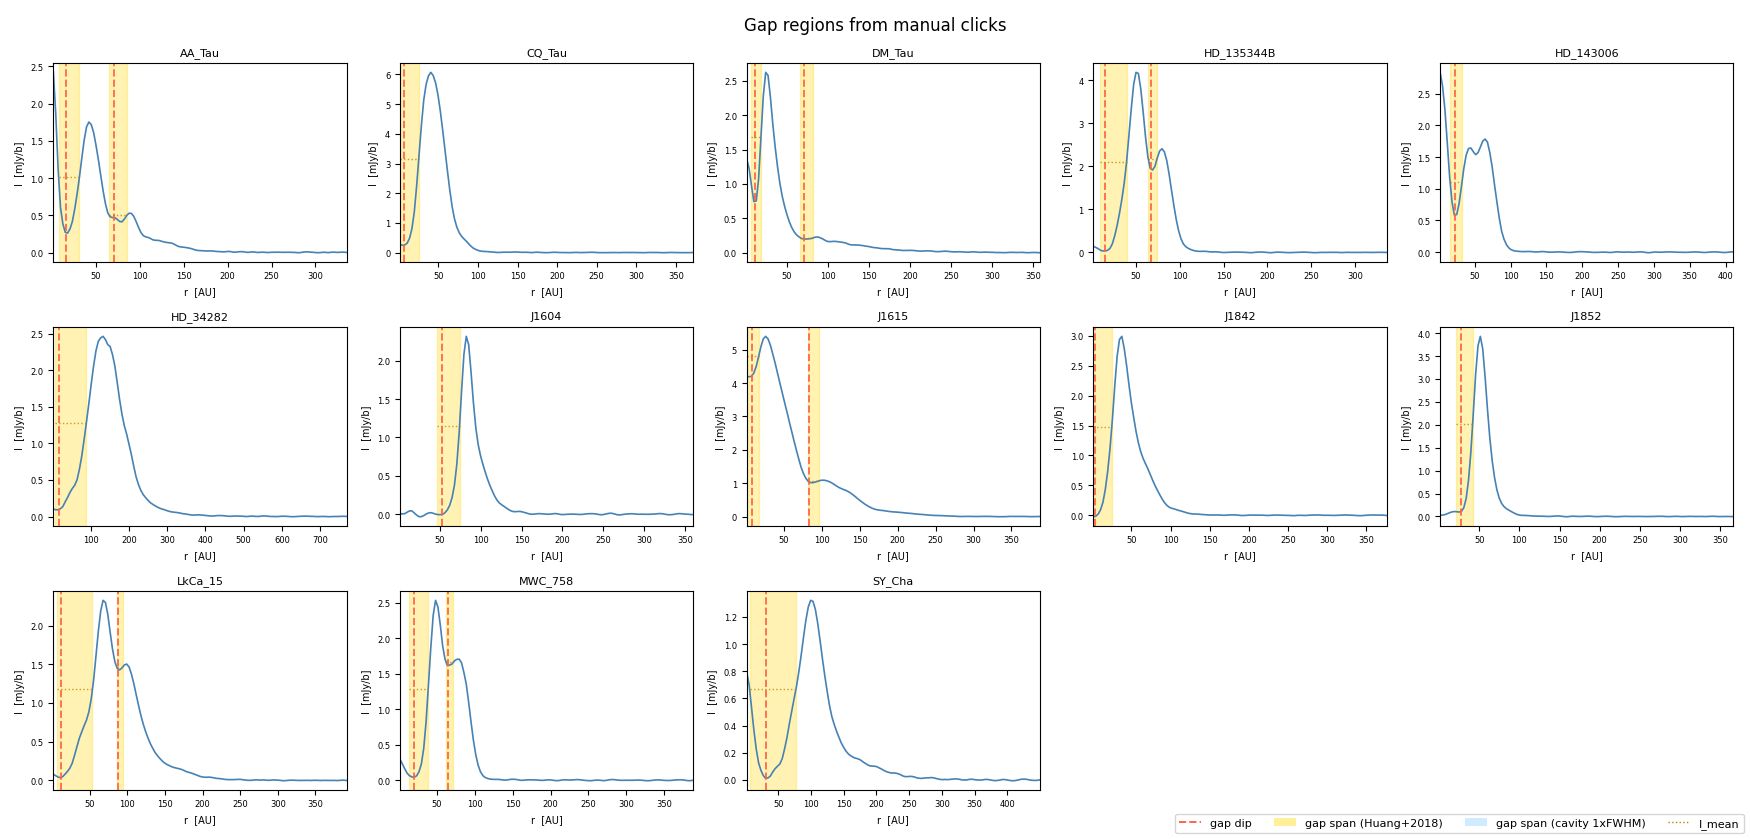

Saved: D:\CPD_MPIA\Injection_Recovery_Revised\gap_highlights.png


In [65]:
# ── Plot gap-highlighted profiles for all clicked disks ─────────────────
import pandas as pd
import matplotlib.pyplot as plt

if not os.path.isfile(LOG_FILE):
    print('No clicks saved yet.')
else:
    df = pd.read_csv(LOG_FILE)
    clicked_disks = sorted(df['disk'].unique())
    print(f'{len(clicked_disks)} disks with saved clicks: {clicked_disks}')

    ncols = 5
    nrows = int(np.ceil(len(clicked_disks) / ncols))
    fig2, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows))
    axes = np.array(axes).flatten()

    for i, disk in enumerate(clicked_disks):
        ax = axes[i]
        try:
            r_as, r_au, I, dI = load_profile(disk)
        except Exception as e:
            ax.text(0.5, 0.5, f'profile missing\n{e}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7, color='red')
            ax.set_title(disk, fontsize=8); continue

        ax.plot(r_au, I, color='steelblue', lw=1.2)

        # group rows into gap sets — each gap_dip starts a new set
        sub = df[df['disk'] == disk].reset_index(drop=True)
        gap_sets, cur = [], {}
        for _, row in sub.iterrows():
            lbl = row['label']
            if lbl == 'gap_dip':
                if cur: gap_sets.append(cur)
                cur = {'gap_dip': row['r_au'],
                       'I_mean':  row.get('I_mean', None),
                       'method':  row.get('method', 'huang2018')}
            elif lbl == 'inner_edge': cur['inner_edge'] = row['r_au']
            elif lbl == 'outer_edge': cur['outer_edge'] = row['r_au']
        if cur: gap_sets.append(cur)

        for gs in gap_sets:
            if 'gap_dip' in gs:
                ax.axvline(gs['gap_dip'], color='tomato', lw=1.4, ls='--', alpha=0.9)
            if 'inner_edge' in gs and 'outer_edge' in gs:
                color = 'lightskyblue' if gs['method'] == 'cavity_1fwhm' else 'gold'
                ax.axvspan(gs['inner_edge'], gs['outer_edge'], alpha=0.3, color=color)
                if gs['I_mean'] is not None:
                    ax.hlines(gs['I_mean'], gs['inner_edge'], gs['outer_edge'],
                              colors='darkgoldenrod', lw=1.0, ls=':', alpha=0.8)

        ax.set_title(disk, fontsize=8)
        ax.set_xlabel('r  [AU]', fontsize=7)
        ax.set_ylabel('I  [mJy/b]', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlim(r_au.min(), r_au.max())

    for j in range(len(clicked_disks), len(axes)):
        axes[j].set_visible(False)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0], [0], color='tomato',        lw=1.4, ls='--', label='gap dip'),
        Patch(facecolor='gold',        alpha=0.4,           label='gap span (Huang+2018)'),
        Patch(facecolor='lightskyblue', alpha=0.4,          label='gap span (cavity 1xFWHM)'),
        Line2D([0], [0], color='darkgoldenrod', lw=1.0, ls=':', label='I_mean'),
    ]
    fig2.legend(handles=legend_els, loc='lower right',
                fontsize=8, ncol=4, bbox_to_anchor=(1.0, 0.0))

    plt.suptitle('Gap regions from manual clicks', fontsize=12)
    plt.tight_layout()

    out_png = os.path.join(os.path.dirname(LOG_FILE), 'gap_highlights.png')
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')
